In [1]:

!pip install -q transformers datasets accelerate scikit-learn pandas "numpy<2.3.0" matplotlib seaborn

In [2]:

import pandas as pd
import numpy as np
import re
import pickle
import torch
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import warnings
from IPython.display import display

"""Tắt cảnh báo rác trên màn hình"""
warnings.filterwarnings('ignore')

In [3]:

DATA_PATH = '/kaggle/input/datasets/ncthanh180/data-full/HQ_2025.csv'
MODEL_SAVE_PATH = '/kaggle/working/model'
CHECKPOINT_PATH = '/kaggle/working/model/checkpoints'

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("Đang đọc dữ liệu từ Kaggle Input...")
try:
    df_train = pd.read_csv(DATA_PATH, encoding='utf-8', on_bad_lines='skip', low_memory=False, dtype=str)
except:
    df_train = pd.read_csv(DATA_PATH, encoding='latin1', on_bad_lines='skip', low_memory=False, dtype=str)

"""Loại bỏ các dòng không có tên hàng"""
df_train = df_train.dropna(subset=['Tên hàng'])
print(f"Số dòng dữ liệu ban đầu: {len(df_train)}")

"""Hiển thị dữ liệu trực quan"""
display(df_train.head())

Đang đọc dữ liệu từ Kaggle Input...
Số dòng dữ liệu ban đầu: 310294


,Ngày,Mã HS,Công ty NK,Tên hàng,DVT,Lượng,Giá trị,Đơn giá,Unnamed: 8,Hãng,...,Quốc gia,Châu lục,MDSD,Công ty XK,Incoterms,Method_of_Payment,Công suất.1,Loại 1,Loại 2,Năm
0,Tháng 1,94056190,CôNG TY TNHH OHSUNG VINA THáI BìNH,#&Biển hiệu công ty được chiếu sáng bằng đèn l...,Pieces,1,1520,1519.71,NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH XAY DUNG MIRAE,DAP,KC,NaN,NaN,NaN,NaN
1,Tháng 1,94054990,CôNG TY TNHH DONGKWANG,"#&Bóng đèn 600x600 48W,hàng mới 100%",Pieces,30,485,16.18,NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH DN 365,DAP,KC,NaN,NaN,NaN,NaN
2,Tháng 1,85395290,CôNG TY TNHH OGK HANOI,"#&Bóng đèn led 60cm, là loại bóng đèn tuýp led...",Pieces,50,119,2.38,NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH MOT THANH VIEN HA MINH TRUONG,DAP,KC,NaN,NaN,NaN,NaN
3,Tháng 1,85395290,CôNG TY TNHH OGK HANOI,"#&Bóng đèn led Rạng Đông 20W, là loại bóng đèn...",Pieces,200,556,2.78,NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH MOT THANH VIEN HA MINH TRUONG,DAP,KC,NaN,NaN,NaN,NaN
4,Tháng 1,85392190,CôNG TY TNHH ĐIệN Tử SNC VIệT NAM,".#&Đèn halogen hiệu chỉnh thiết bị D204C, điện...",Pieces,3,246,82.06,NaN,NaN,...,China (CN),Asia,NaN,HONGKONG SNC LIGHTING CO LTD,CIF,OA,NaN,NaN,NaN,NaN


Tổng số nhãn phân loại: 81
--- KẾT QUẢ CHIA TẬP DATA ---
Train: 248217 mẫu | Val: 31027 mẫu | Test: 31028 mẫu


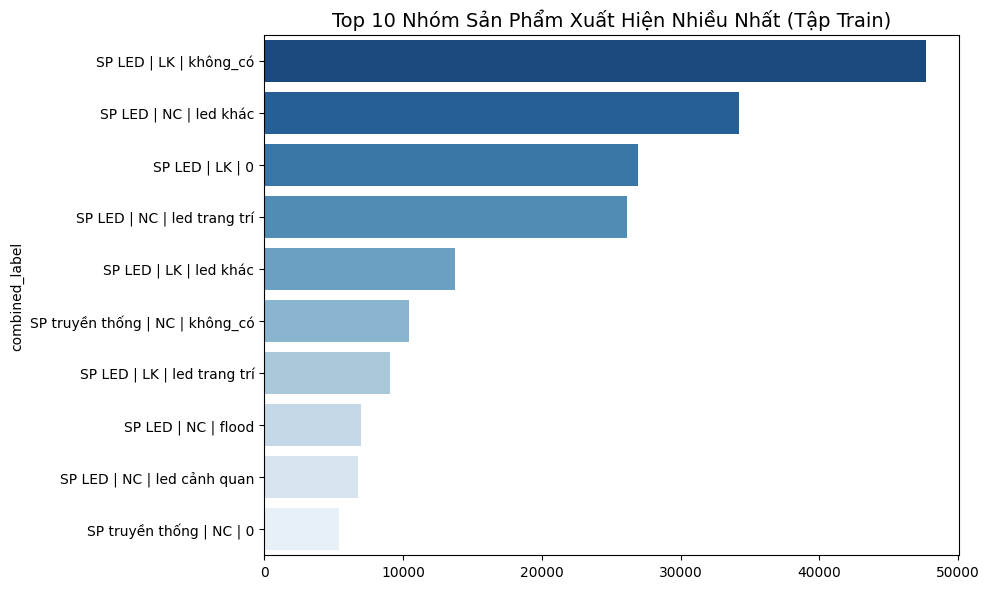

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]', ' ', text)
    return ' '.join(text.split()).strip()
    
df_train.fillna('', inplace=True)
df_train['text'] = "Hãng: " + df_train['Hãng'].astype(str) + " - Công suất: " + df_train['Công suất'].astype(str) + " - Sản phẩm: " + df_train['Tên hàng'].astype(str)
df_train['text'] = df_train['text'].apply(clean_text)
df_train = df_train[df_train['text'] != '']
cols_to_predict = ['Dòng SP', 'Loại', 'Lớp 1']
for col in cols_to_predict:
    df_train[col] = df_train[col].replace('', 'không_có')

df_train['combined_label'] = df_train['Dòng SP'] + " | " + df_train['Loại'] + " | " + df_train['Lớp 1']

"""Lọc nhãn rác (xuất hiện dưới 5 lần)"""
label_counts = df_train['combined_label'].value_counts()
valid_labels = label_counts[label_counts >= 5].index
df_train = df_train[df_train['combined_label'].isin(valid_labels)]

"""Mã hóa nhãn"""
label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['combined_label'])
num_labels = len(label_encoder.classes_)
print(f"Tổng số nhãn phân loại: {num_labels}")

"""Chia tập dữ liệu chuẩn 80/10/10"""
train_df, temp_df = train_test_split(df_train[['text', 'label', 'Tên hàng', 'combined_label']], test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
test_df = test_df.copy()

print("--- KẾT QUẢ CHIA TẬP DATA ---")
print(f"Train: {len(train_df)} mẫu | Val: {len(val_df)} mẫu | Test: {len(test_df)} mẫu")

"""Vẽ biểu đồ phân bổ dữ liệu"""
plt.figure(figsize=(10, 6))
top_labels = train_df['combined_label'].value_counts().head(10)
sns.barplot(x=top_labels.values, y=top_labels.index, palette='Blues_r')
plt.title('Top 10 Nhóm Sản Phẩm Xuất Hiện Nhiều Nhất (Tập Train)', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
model_name = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
train_dataset = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
val_dataset = Dataset.from_pandas(val_df).map(tokenize_function, batched=True)
test_dataset = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir=CHECKPOINT_PATH,
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,   
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,                       
    report_to="none",
    warmup_ratio=0.1,
    lr_scheduler_type="cosine"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,        
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN ---")
trainer.train()

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=23271, training_loss=1.4050757774637272, metrics={'train_runtime': 11952.0917, 'train_samples_per_second': 62.303, 'train_steps_per_second': 1.947, 'total_flos': 4.901622063016781e+16, 'train_loss': 1.4050757774637272, 'epoch': 3.0})


--- TIẾN HÀNH THI CHỨNG CHỈ TRÊN TẬP TEST ĐỘC LẬP (10%) ---


ĐỘ CHÍNH XÁC THỰC TẾ TRÊN TẬP TEST: 83.75%



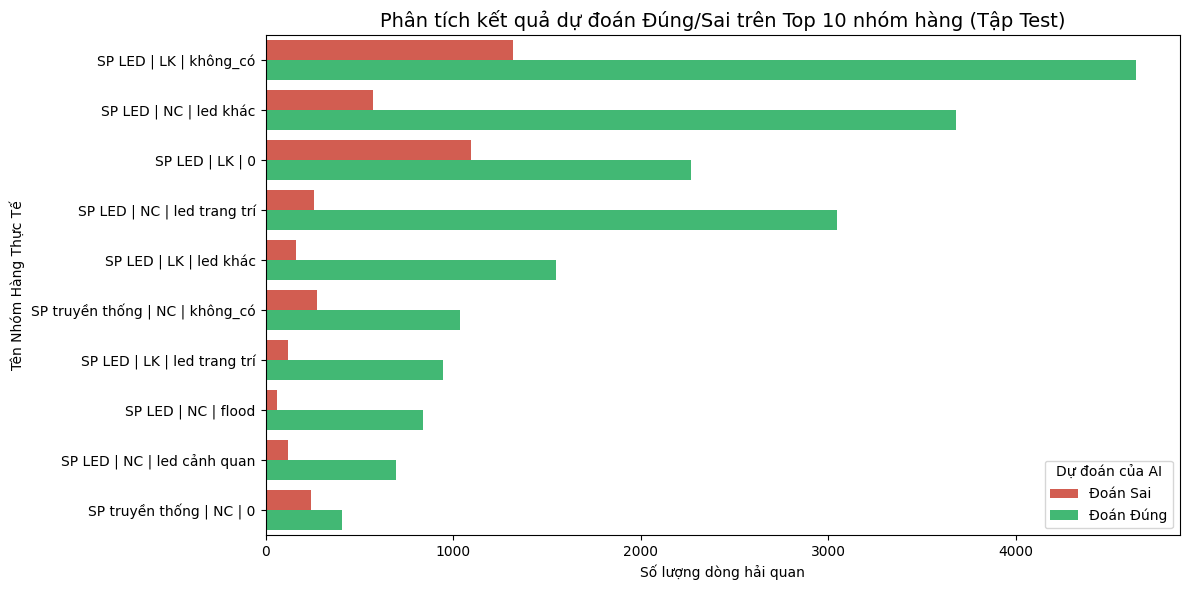

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Hoàn tất! Model, file label_encoder và file CSV kết quả đều đã được lưu trực tiếp tại: /kaggle/working/
Bạn có thể tải ngay các file này ở bảng Output bên tay phải màn hình Kaggle.


In [6]:
print("\n--- TIẾN HÀNH THI CHỨNG CHỈ TRÊN TẬP TEST ĐỘC LẬP (10%) ---")

test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

test_acc = accuracy_score(test_labels, test_preds)
print(f"==========================================================")
print(f"ĐỘ CHÍNH XÁC THỰC TẾ TRÊN TẬP TEST: {test_acc * 100:.2f}%")
print(f"==========================================================\n")

"""Giải mã số thành nhãn chữ"""
test_df['predicted_label'] = label_encoder.inverse_transform(test_preds)
test_df['is_correct'] = test_df['combined_label'] == test_df['predicted_label']
top_test_labels = test_df['combined_label'].value_counts().head(10).index
test_df_top = test_df[test_df['combined_label'].isin(top_test_labels)].copy()

plt.figure(figsize=(12, 6))
sns.countplot(
    data=test_df_top, 
    y='combined_label', 
    hue='is_correct', 
    order=top_test_labels, 
    palette={True: '#2ecc71', False: '#e74c3c'}
)
plt.title('Phân tích kết quả dự đoán Đúng/Sai trên Top 10 nhóm hàng (Tập Test)', fontsize=14)
plt.xlabel('Số lượng dòng hải quan')
plt.ylabel('Tên Nhóm Hàng Thực Tế')
plt.legend(title='Dự đoán của AI', labels=['Đoán Sai', 'Đoán Đúng'])
plt.tight_layout()
plt.show()


THU_MUC_LUU_TRUC_TIEP = '/kaggle/working/'
trainer.save_model(THU_MUC_LUU_TRUC_TIEP)
with open(f"{THU_MUC_LUU_TRUC_TIEP}label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

